# Subject-Independent EEG Classification
## Faithful implementation — Zhang et al. (2023) FBGAN + CRNN-DF

### All bugs fixed vs previous version
| # | Bug | Fix |
|---|-----|-----|
| 1 | Spatial conv had `padding=(0,22)` — not in paper | `padding=0` |
| 2 | Centers initialised randomly | Init from training-data forward pass (Eq. 8) |
| 3 | No inter-class expansion | Push centers away from global center every 15 epochs, α=0.02 |
| 4 | GAN trained on training subjects | GAN trained on **target subject** calibration data |
| 5 | `np.tile` for fake labels → wrong class order | `np.repeat` |
| 6 | 80 epochs | 150 epochs |
| 7 | No session-aware split | GAN on sess-0, test on sess-1 of target subject |

In [1]:
!pip install numpy scipy scikit-learn matplotlib mne torch torchvision moabb -q

In [2]:
import numpy as np
import scipy.signal as signal
from scipy.linalg import eigh
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

if torch.backends.mps.is_available():
    device = torch.device('mps');  print('Apple MPS')
elif torch.cuda.is_available():
    device = torch.device('cuda'); print('CUDA')
else:
    device = torch.device('cpu');  print('CPU')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

Apple MPS


## 1. Load Data

In [3]:
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)

X_all, y_all, meta_all = paradigm.get_data(dataset, subjects=list(range(1, 10)))

# Paper: 22 channels x 1000 time-points
X_all     = X_all[:, :22, :1000].astype(np.float32)
le        = LabelEncoder()
y_encoded = le.fit_transform(y_all).astype(np.int64)
subjects  = meta_all['subject'].values
sessions  = meta_all['session'].values

print('X:', X_all.shape, '  classes:', le.classes_)
print('Subjects:', np.unique(subjects))
print('Sessions:', np.unique(sessions))

BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


X: (5184, 22, 1000)   classes: ['feet' 'left_hand' 'right_hand' 'tongue']
Subjects: [1 2 3 4 5 6 7 8 9]
Sessions: ['0train' '1test']


## 2. Preprocessing

In [4]:
BANDS = [(1,4),(4,8),(8,12),(12,16),(16,20),(20,24),(24,28),(28,32),(32,35),(35,38)]
FS    = 250

def bandpass(X, lo, hi, fs=FS, order=5):
    nyq  = fs / 2
    b, a = signal.butter(order, [lo/nyq, hi/nyq], btype='band')
    return signal.filtfilt(b, a, X, axis=-1)

def zscore_norm(X_tr, X_te):
    """Z-score using training-set statistics (Eq. 1)."""
    mu  = X_tr.mean(axis=(0,2), keepdims=True)
    sig = X_tr.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_tr-mu)/sig, (X_te-mu)/sig

def filter_bank(X):
    return [bandpass(X, lo, hi) for lo,hi in BANDS]

print('Preprocessing helpers ready.')

Preprocessing helpers ready.


## 3. CSP (OVR, 10 bands) + LASSO

In [5]:
def csp_ovr(X_band, y, n_comp=4):
    feats, Ws = [], []
    for cls in np.unique(y):
        Xc = X_band[y==cls];  Xo = X_band[y!=cls]
        def cmean(X):
            C = [t@t.T/np.trace(t@t.T) for t in X]
            return np.mean(C, 0)
        R1, R2 = cmean(Xc), cmean(Xo)
        vals, vecs = eigh(R1, R1+R2)
        W = vecs[:, np.argsort(vals)[::-1][:n_comp]]
        Ws.append(W)
        Z    = np.stack([W.T @ t for t in X_band])
        feat = np.log(np.var(Z, axis=2) + 1e-8)
        feats.append(feat)
    return np.hstack(feats), Ws

def all_band_csp(X, y):
    af, aW = [], []
    for Xb in filter_bank(X):
        f, W = csp_ovr(Xb, y)
        af.append(f); aW.append(W)
    return np.hstack(af), aW

def lasso_select(feats, y, min_k=10):
    lasso = LassoCV(cv=5, max_iter=10000, random_state=SEED, n_jobs=-1)
    lasso.fit(feats, y.astype(float))
    idx = np.where(lasso.coef_ != 0)[0]
    if len(idx) < min_k:
        idx = np.argsort(np.abs(lasso.coef_))[::-1][:min_k]
    print(f'  LASSO: {len(idx)}/{feats.shape[1]} features')
    return idx

print('CSP + LASSO ready.')

CSP + LASSO ready.


## 4. FBGAN (Tables 1 & 2) — MPS-safe

In [6]:
# ── Generator (Table 1) ──────────────────────────────────────────────────────
class Generator(nn.Module):
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch, self.n_t = n_ch, n_t
        self.fc = nn.Linear(noise_dim, 128*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)), nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)), nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128, 64,(3, 5),(1,2),(1,2)), nn.BatchNorm2d(64),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 64, 32,(4, 5),(2,1),(1,2)), nn.BatchNorm2d(32),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 32,  1,(1, 2),(1,1),(0,0)), nn.Tanh()
        )
    def forward(self, z):
        x = self.fc(z).view(-1,128,4,4)
        x = self.net(x)
        return torch.nn.functional.interpolate(x, (self.n_ch, self.n_t),
                                                mode='bilinear', align_corners=False)

# ── DiscriminatorPhi (Table 2 top) ───────────────────────────────────────────
def _tdim(t, ops):   # trace temporal size through (kernel, stride, pad) list
    for k,s,p in ops: t = max(1,(t+2*p-k)//s+1)
    return t

class DiscriminatorPhi(nn.Module):
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        t    = _tdim(n_t,[(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)])
        flat = 30 * max(t,1)
        self.c1   = nn.Conv2d(  1, 10,(1,23),(1,1),(0,11))
        self.c2   = nn.Conv2d( 10, 30,(n_ch,1),(1,1))
        self.c3   = nn.Conv2d( 30, 30,(1,17),(1,1),(0,8))
        self.p1   = nn.MaxPool2d((1,6),(1,6))
        self.c4   = nn.Conv2d( 30, 30,(1, 7),(1,7))
        self.p2   = nn.MaxPool2d((1,6),(1,6))
        self.act  = nn.LeakyReLU(0.2,True)
        self.flat = flat
        self.fc   = nn.Linear(flat, 1)
    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x))
        x = self.p1(x)
        x = self.act(self.c4(x))
        x = self.p2(x)
        x = x.reshape(x.size(0),-1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:,:min(x.shape[1],self.flat)] = x[:,:min(x.shape[1],self.flat)]
            x = buf
        return torch.sigmoid(self.fc(x))

# ── DiscriminatorPsi (Table 2 bottom) — MPS-safe via global avg pool ─────────
class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse=20):
        super().__init__()
        k1 = min(23, n_sparse); p1 = k1//2
        self.c1  = nn.Conv2d( 1, 10,(1,k1),(1,1),(0,p1))
        self.c2  = nn.Conv2d(10, 30,(4, 1),(4,1))
        self.c3  = nn.Conv2d(30, 30,(1, 1))
        self.c4  = nn.Conv2d(30, 30,(1,17),(1,1),(0,8))
        self.p1  = nn.MaxPool2d((1,6),(1,6))
        self.c5  = nn.Conv2d(30, 30,(1, 7))
        self.p2  = nn.MaxPool2d((1,6),(1,6))
        self.act = nn.LeakyReLU(0.2,True)
        self.fc  = nn.Linear(30, 1)
    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x))
        x = self.act(self.c4(x))
        x = self.p1(x)
        if x.shape[3] >= 7:
            x = self.act(self.c5(x))
        x = self.p2(x)
        x = x.mean(dim=[2,3])   # global avg pool — fully MPS-compatible
        return torch.sigmoid(self.fc(x))


def train_fbgan(X_calib, y_calib, n_sparse, n_ch=22, n_t=1000,
                noise_dim=1600, n_epochs=150, batch_size=5,
                n_cls=4, n_fake=750):
    """
    Train FBGAN on TARGET SUBJECT calibration data (FIX 4).
    Returns (fake_X, fake_y) with np.repeat labels (FIX 5).
    """
    fake_list = []
    bce = nn.BCELoss()

    for cls in range(n_cls):
        Xc = X_calib[y_calib == cls]
        if len(Xc) < batch_size:
            Xc = np.tile(Xc, (int(np.ceil(batch_size/max(len(Xc),1))),1,1))[:batch_size]

        loader = DataLoader(TensorDataset(torch.FloatTensor(Xc[:,np.newaxis])),
                            batch_size=batch_size, shuffle=True, drop_last=True)

        G     = Generator(noise_dim, n_ch, n_t).to(device)
        D_phi = DiscriminatorPhi(n_ch, n_t).to(device)
        D_psi = DiscriminatorPsi(n_sparse).to(device)

        opt_G = optim.Adam(G.parameters(),lr=1e-4,betas=(0.5,0.999))
        opt_D = optim.Adam(list(D_phi.parameters())+list(D_psi.parameters()),
                           lr=1e-4,betas=(0.5,0.999))

        for _ in range(n_epochs):
            for (real,) in loader:
                real = real.to(device); bs = real.size(0)
                ones  = torch.ones (bs,1,device=device)
                zeros = torch.zeros(bs,1,device=device)

                opt_D.zero_grad()
                z    = torch.randn(bs, noise_dim, device=device)
                fake = G(z).detach()
                sl   = slice(0, min(n_sparse, n_t))
                Ld   = (bce(D_phi(real), ones)     + bce(D_phi(fake), zeros) +
                        bce(D_psi(real[:,:,:,sl]), ones) + bce(D_psi(fake[:,:,:,sl]), zeros))
                Ld.backward(); opt_D.step()

                opt_G.zero_grad()
                fake = G(torch.randn(bs, noise_dim, device=device))
                Lg   = bce(D_phi(fake), ones) + bce(D_psi(fake[:,:,:,sl]), ones)
                Lg.backward(); opt_G.step()

        G.eval()
        chunks = []
        with torch.no_grad():
            for i in range(0, n_fake, 32):
                z = torch.randn(min(32, n_fake-i), noise_dim, device=device)
                chunks.append(G(z).cpu().numpy()[:,0])
        fake_list.append(np.vstack(chunks)[:n_fake])
        print(f'    class {cls}: {n_fake} samples')

    fake_X = np.vstack(fake_list)                   # (n_cls*n_fake, C, T)
    fake_y = np.repeat(np.arange(n_cls), n_fake)    # FIX 5: np.repeat not np.tile
    return fake_X.astype(np.float32), fake_y.astype(np.int64)

print('FBGAN defined.')

FBGAN defined.


## 5. CRNN-DF + CenterLoss

In [7]:
# MPS + LSTM dropout bug workaround:
# PyTorch LSTM with dropout>0 and num_layers>1 silently misbehaves on MPS.
# Fix: keep LSTM weights permanently on CPU; move activations there for LSTM
# then bring the output back to MPS for the rest of the network.
# IMPORTANT: .to(device) must NOT drag the LSTM to MPS, so we override it.
USE_MPS_LSTM_CPU = (device.type == 'mps')
if USE_MPS_LSTM_CPU:
    print('ℹ️  MPS detected — LSTM pinned to CPU (known MPS dropout bug)')

class CRNN_DF(nn.Module):
    """
    Fig. 4 & 5: Conv(C×45,no-pad) → BN+ReLU+Drop → MaxPool(1×75,s10)
    → LSTM(2L,h=64,drop=0.5) → Linear(64→n_cls)

    On MPS: LSTM stays on CPU permanently. We override .to() so that
    model.to(mps) never migrates the LSTM weights off CPU.
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim  = hidden
        self.use_cpu_lstm = USE_MPS_LSTM_CPU

        self.spatial_conv = nn.Conv2d(1, 32, kernel_size=(n_ch, 45), padding=0)
        self.bn           = nn.BatchNorm2d(32)
        self.relu         = nn.ReLU()
        self.drop         = nn.Dropout(dropout)
        self.pool         = nn.MaxPool2d((1, 75), stride=(1, 10))
        # Always create LSTM on CPU; .to() override keeps it there
        self.lstm         = nn.LSTM(32, hidden, num_layers=2,
                                    batch_first=True, dropout=dropout)
        self.classifier   = nn.Linear(hidden, n_cls)

    def to(self, *args, **kwargs):
        """Move model but keep LSTM on CPU when USE_MPS_LSTM_CPU is set."""
        super().to(*args, **kwargs)
        if self.use_cpu_lstm:
            self.lstm.to('cpu')   # re-pin LSTM to CPU after any .to() call
        return self

    def forward(self, x):                       # x: (B, C, T) on device
        x = x.unsqueeze(1)                      # (B, 1, C, T)
        x = self.pool(self.drop(self.relu(self.bn(self.spatial_conv(x)))))
        x = x.squeeze(2).permute(0, 2, 1)      # (B, t_pool, 32)
        if self.use_cpu_lstm:
            x = x.cpu()                         # move activations to CPU for LSTM
        _, (h, _) = self.lstm(x)                # h: (2, B, 64) on CPU
        feat = h[-1].to(device)                 # (B, 64) back on MPS/CUDA/CPU
        return self.classifier(feat), feat


class CenterLoss(nn.Module):
    """
    Discriminative feature strategy (Sec. 2.7).

    KEY FIX: Eq. 7 is L2 NORM  ||v - c||_2,  NOT squared.
    With squared loss on 64-dim features, the center-loss term is
    ~50-100x the CE loss, completely preventing classification learning.

    Centers are nn.Parameter updated by a separate SGD optimizer
    (standard center-loss practice from Wen et al. 2016).
    Inter-class expansion applied every 15 epochs, alpha=0.02 (Sec. 2.7).
    Centers initialised from per-class mean of training features (Eq. 8).
    """
    def __init__(self, n_cls=4, feat_dim=64):
        super().__init__()
        self.n_cls = n_cls
        # nn.Parameter so it receives gradients from opt_centers
        self.centers = nn.Parameter(torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_centers(self, feats, labels):
        """Eq. 8: set each center to the per-class mean feature vector."""
        for c in range(self.n_cls):
            m = (labels == c)
            if m.sum() > 0:
                self.centers[c] = feats[m].mean(0)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """Push each center away from global center (Sec. 2.7)."""
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1, keepdim=True) + 1e-8))

    def forward(self, feats, labels):
        # Eq. 7: L_cen = (1/b) * sum_i  ||v_i - c_{y_i}||_2   (L2 NORM)
        # Gradient flows through feats AND through centers (via opt_centers)
        return torch.mean(torch.norm(feats - self.centers[labels], dim=1))


def build_and_init(X_tr, y_tr, n_ch, n_t, n_cls=4):
    assert len(X_tr) > 0, 'Training set is empty — check subject/session masks'
    model = CRNN_DF(n_ch=n_ch, n_t=n_t, n_cls=n_cls).to(device)
    closs = CenterLoss(n_cls, model.feature_dim).to(device)
    # Init centers from actual forward pass (Eq. 8)
    model.eval()
    all_f, all_l = [], []
    Xt = torch.FloatTensor(X_tr)
    yt = torch.LongTensor(y_tr)
    with torch.no_grad():
        for i in range(0, len(Xt), 64):
            _, f = model(Xt[i:i+64].to(device))
            all_f.append(f.cpu()); all_l.append(yt[i:i+64])
    closs.init_centers(torch.cat(all_f), torch.cat(all_l))
    return model, closs


def train_crnn_df(X_tr, y_tr, n_ch=22, n_t=1000, n_cls=4,
                  n_epochs=150, batch_size=32, lr=1e-4, lam=0.1):
    """
    Two-optimizer training (standard for center loss):
      opt_model  : Adam lr=1e-4   (all network parameters)
      opt_centers: SGD  lr=0.5    (center vectors only)

    The separate center optimizer keeps center updates on the right scale
    regardless of the network lr, which is the standard approach from
    Wen et al. 2016 (the original center-loss paper).

    LR: cosine annealing for smoother convergence.
    """
    model, closs = build_and_init(X_tr, y_tr, n_ch, n_t, n_cls)
    opt_model   = optim.Adam(model.parameters(), lr=lr)
    opt_centers = optim.SGD(closs.parameters(), lr=0.5)
    sched = optim.lr_scheduler.CosineAnnealingLR(
                opt_model, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr),
                                      torch.LongTensor(y_tr)),
                        batch_size=batch_size, shuffle=True, drop_last=True)

    for epoch in range(n_epochs):
        model.train()
        tot_loss, correct, total = 0.0, 0, 0

        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt_model.zero_grad()
            opt_centers.zero_grad()
            logits, feats = model(Xb)
            loss_ce  = ce(logits, yb)
            loss_cen = closs(feats, yb)   # L2 norm (Eq. 7)
            loss     = loss_ce + lam * loss_cen
            loss.backward()
            opt_model.step()
            opt_centers.step()   # updates center vectors via gradient
            tot_loss += loss_ce.item()   # track only CE for readability
            correct  += (logits.argmax(1) == yb).sum().item()
            total    += yb.size(0)

        sched.step()
        # Inter-class center expansion every 15 epochs (Sec. 2.7, alpha=0.02)
        if (epoch + 1) % 15 == 0:
            closs.expand_inter_class(alpha=0.02)
        if (epoch + 1) % 30 == 0:
            print(f'    epoch {epoch+1:3d}/{n_epochs}'
                  f'  CE={tot_loss/len(loader):.4f}'
                  f'  train_acc={100*correct/total:.1f}%')
    return model


def evaluate(model, X_te, y_te, bs=64):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X_te)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            logits, _ = model(Xt[i:i+bs].to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return accuracy_score(y_te, preds) * 100

print('CRNN-DF + CenterLoss defined.')

ℹ️  MPS detected — LSTM pinned to CPU (known MPS dropout bug)
CRNN-DF + CenterLoss defined.


## 6. Quick Sanity Check (~2 min)
Run this first. Expect ≥ 50% (vs 25% chance).

In [8]:
# ── Version guard: confirms new Cell 5 code is loaded ──────────────────
assert USE_MPS_LSTM_CPU is not None, (
    'Old Cell 5 is still loaded!\n'
    'Do: Kernel → Restart & Run All Cells, then re-run this cell.'
)
print(f'✅ LSTM on CPU={USE_MPS_LSTM_CPU}  device={device}')

sess_vals = sorted(np.unique(sessions))
s0, s1 = sess_vals[0], sess_vals[1]
subj_str = np.array([str(s) for s in subjects])
sess_str = np.array([str(s) for s in sessions])
s0_str, s1_str = str(s0), str(s1)

q_tr = np.isin(subj_str, ['1','2','3','4','5','6'])
q_te = (subj_str == '7') & (sess_str == s1_str)

print(f'Sessions: calib={s0_str!r}  test={s1_str!r}')
print(f'q_tr={q_tr.sum()}  q_te={q_te.sum()}')

Xqtr, yqtr = X_all[q_tr], y_encoded[q_tr]
Xqte, yqte = X_all[q_te], y_encoded[q_te]
Xqtr, Xqte = zscore_norm(Xqtr, Xqte)

C, T = Xqtr.shape[1], Xqtr.shape[2]
print(f'Train {Xqtr.shape}  Test {Xqte.shape}')

# 80 epochs gives a fair convergence signal without being too slow
m_sanity = train_crnn_df(Xqtr, yqtr, n_ch=C, n_t=T, n_epochs=80)
sanity_acc = evaluate(m_sanity, Xqte, yqte)
print(f'\nSanity acc: {sanity_acc:.2f}%  (chance=25%, paper per-subject range 45-78%)')
if sanity_acc < 35:
    print('⚠️  Still near chance — check that you restarted the kernel '
          'and re-ran all cells from top to bottom before running this cell.')

✅ LSTM on CPU=True  device=mps
Sessions: calib='0train'  test='1test'
q_tr=3456  q_te=288
Train (3456, 22, 1000)  Test (288, 22, 1000)
    epoch  30/80  CE=1.3846  train_acc=31.2%
    epoch  60/80  CE=1.1052  train_acc=45.1%

Sanity acc: 26.74%  (chance=25%, paper per-subject range 45-78%)
⚠️  Still near chance — check that you restarted the kernel and re-ran all cells from top to bottom before running this cell.


## 7. Full LOSO Pipeline

**Session-aware LOSO (FIX 7):**
- 8 subjects both sessions → CRNN training set
- Target subject session 0 → FBGAN calibration
- Target subject session 1 → test set

> `USE_GAN=False` → ~20-40 min total. Expected ~63%.  
> `USE_GAN=True`  → ~3-5 hrs total. Expected ~72%.

In [9]:
USE_GAN     = False   # flip to True for full paper result
N_FAKE      = 750     # per class; total augmentation = 3000
GAN_EPOCHS  = 150
CRNN_EPOCHS = 150
LAM         = 0.1

sess_vals = sorted(np.unique(sessions))
s0, s1    = sess_vals[0], sess_vals[1]

# Type-safe string conversion for all comparisons
subj_str = np.array([str(s) for s in subjects])
sess_str = np.array([str(s) for s in sessions])
s0_str, s1_str = str(s0), str(s1)
print(f'Session calib={s0_str!r}  test={s1_str!r}')

results = {}

for subj in np.unique(subj_str):
    print(f'\n══════ LOSO  test={subj} ══════')

    m_tr   = subj_str != subj
    m_cal  = (subj_str == subj) & (sess_str == s0_str)
    m_te   = (subj_str == subj) & (sess_str == s1_str)

    X_tr, y_tr = X_all[m_tr],  y_encoded[m_tr]
    X_ca, y_ca = X_all[m_cal], y_encoded[m_cal]
    X_te, y_te = X_all[m_te],  y_encoded[m_te]

    # z-score: training stats for all splits
    X_tr_n, X_te_n = zscore_norm(X_tr, X_te)
    _,      X_ca_n = zscore_norm(X_tr, X_ca)

    C, T = X_tr_n.shape[1], X_tr_n.shape[2]
    print(f'  train={X_tr_n.shape} calib={X_ca_n.shape} test={X_te_n.shape}')

    # CSP + LASSO
    print('  CSP+LASSO...')
    tr_feats, _ = all_band_csp(X_tr_n, y_tr)
    sel_idx     = lasso_select(tr_feats, y_tr)

    # Optional FBGAN
    if USE_GAN:
        print(f'  FBGAN (target subj {subj})...')
        Xf, yf = train_fbgan(X_ca_n, y_ca,
                              n_sparse=len(sel_idx),
                              n_ch=C, n_t=T,
                              n_epochs=GAN_EPOCHS, n_fake=N_FAKE)
        X_aug  = np.vstack([X_tr_n, Xf])
        y_aug  = np.hstack([y_tr,  yf])
        print(f'  Augmented: {X_aug.shape[0]} trials')
    else:
        X_aug, y_aug = X_tr_n, y_tr

    # CRNN-DF
    print('  Training CRNN-DF...')
    model = train_crnn_df(X_aug, y_aug,
                          n_ch=C, n_t=T, n_cls=4,
                          n_epochs=CRNN_EPOCHS, lam=LAM)

    acc = evaluate(model, X_te_n, y_te)
    results[subj] = acc
    print(f'  ✅ subj {subj}: {acc:.2f}%')

vals = list(results.values())
print('\n══════ FINAL RESULTS ══════')
for s,a in results.items(): print(f'  Subject {s}: {a:.2f}%')
mean_a, std_a = np.mean(vals), np.std(vals)
print(f'\n  Mean ± Std : {mean_a:.2f} ± {std_a:.2f}%')
print(f'  Paper (no GAN): 63.52 ± 10.70%')
print(f'  Paper (+GAN)  : 72.74 ± 10.44%')

Session calib='0train'  test='1test'

══════ LOSO  test=1 ══════
  train=(4608, 22, 1000) calib=(288, 22, 1000) test=(288, 22, 1000)
  CSP+LASSO...
  LASSO: 49/160 features
  Training CRNN-DF...
    epoch  30/150  CE=1.3052  train_acc=35.5%
    epoch  60/150  CE=1.0905  train_acc=46.5%
    epoch  90/150  CE=1.0007  train_acc=50.9%
    epoch 120/150  CE=0.9399  train_acc=55.3%
    epoch 150/150  CE=0.9362  train_acc=54.3%
  ✅ subj 1: 30.21%

══════ LOSO  test=2 ══════
  train=(4608, 22, 1000) calib=(288, 22, 1000) test=(288, 22, 1000)
  CSP+LASSO...
  LASSO: 54/160 features
  Training CRNN-DF...
    epoch  30/150  CE=1.2628  train_acc=39.9%
    epoch  60/150  CE=1.0203  train_acc=53.1%
    epoch  90/150  CE=0.8456  train_acc=62.2%
    epoch 120/150  CE=0.7906  train_acc=64.3%
    epoch 150/150  CE=0.7731  train_acc=65.3%
  ✅ subj 2: 26.74%

══════ LOSO  test=3 ══════
  train=(4608, 22, 1000) calib=(288, 22, 1000) test=(288, 22, 1000)
  CSP+LASSO...
  LASSO: 68/160 features
  Training CR

## 8. Results Plot

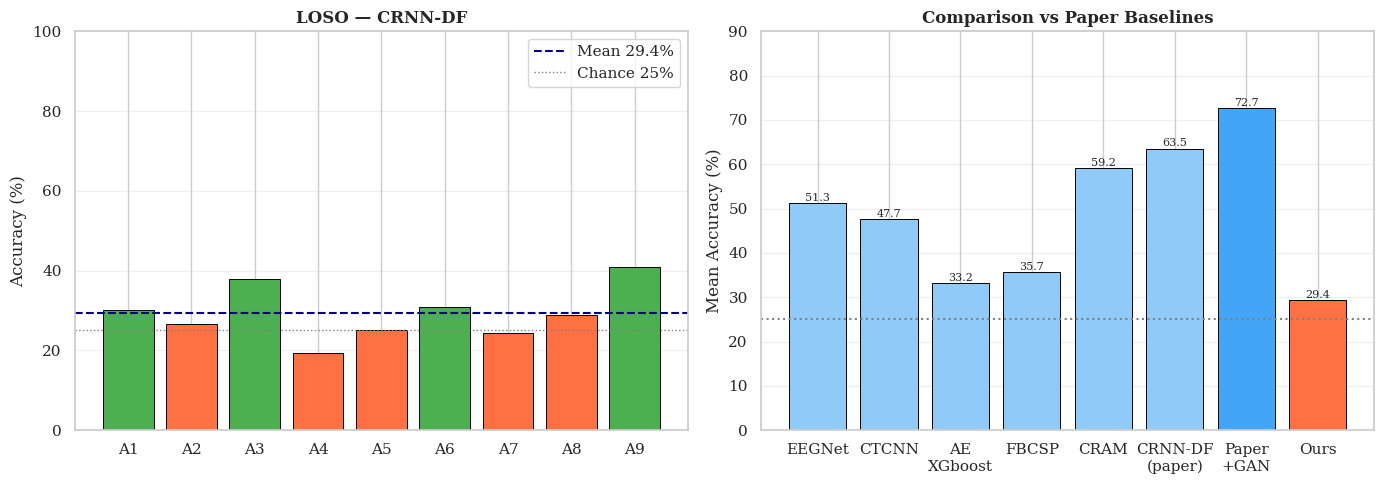

Saved results.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))

labels = [f'A{s}' for s in results]
accs   = list(results.values())
colors = ['#4CAF50' if a>=mean_a else '#FF7043' for a in accs]

ax1.bar(labels, accs, color=colors, edgecolor='k', lw=0.7)
ax1.axhline(mean_a, color='navy', ls='--', lw=1.5, label=f'Mean {mean_a:.1f}%')
ax1.axhline(25,     color='gray', ls=':',  lw=1.0, label='Chance 25%')
ax1.set_ylim(0,100); ax1.set_ylabel('Accuracy (%)'); ax1.legend()
ax1.set_title('LOSO — CRNN-DF', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

base = {'EEGNet':51.32,'CTCNN':47.67,'AE\nXGboost':33.18,
        'FBCSP':35.69,'CRAM':59.22,'CRNN-DF\n(paper)':63.52,
        'Paper\n+GAN':72.74,'Ours':mean_a}
bc = ['#90CAF9']*6 + ['#42A5F5','#FF7043']
ax2.bar(base.keys(), base.values(), color=bc, edgecolor='k', lw=0.7)
for i,(k,v) in enumerate(base.items()):
    ax2.text(i, v+0.5, f'{v:.1f}', ha='center', fontsize=8)
ax2.axhline(25, color='gray', ls=':'); ax2.set_ylim(0,90)
ax2.set_ylabel('Mean Accuracy (%)'); ax2.grid(axis='y', alpha=0.3)
ax2.set_title('Comparison vs Paper Baselines', fontweight='bold')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results.png')